Phase 1: Load & Explore Data (Python + Pandas)

Objective: Inspect the dataset and prepare it for analysis.

In [1]:
import pandas as pd 
df = pd.read_csv("space_environment_dataset.csv")

Inspecting the data

In [2]:
df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Day                     365 non-null    int64  
 1   Solar_Flare_Occurred    365 non-null    int64  
 2   Micrometeoroid_Impacts  365 non-null    int64  
 3   Radiation_Level_mSv     365 non-null    float64
 4   Surface_Temperature_C   365 non-null    float64
 5   Solar_Wind_Speed_km_s   365 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 17.2 KB


,Day,Solar_Flare_Occurred,Micrometeoroid_Impacts,Radiation_Level_mSv,Surface_Temperature_C,Solar_Wind_Speed_km_s
count,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,183.000000,0.287671,5.010959,49.430217,20.287253,395.893615
std,105.510663,0.453298,2.211332,9.823547,4.906922,48.707758
min,1.000000,0.000000,0.000000,15.285701,6.576060,233.762214
25%,92.000000,0.000000,3.000000,42.765372,16.683478,364.756577
50%,183.000000,0.000000,5.000000,49.802509,20.528747,393.259956
75%,274.000000,1.000000,7.000000,56.385179,23.755654,426.945959
max,365.000000,1.000000,11.000000,76.342220,35.309735,534.233712


Filter dataset for one week (first 7 days):

In [18]:
week_data = df[df['Day'].between(1,7)]

Convert Solar_Flare_Occurred to integer

In [19]:
df['Solar_Flare_Occurred'] = df['Solar_Flare_Occurred'].astype(int)
df['Solar_Flare_Occurred'] 

0      0
1      1
2      1
3      0
4      0
      ..
360    0
361    0
362    0
363    0
364    1
Name: Solar_Flare_Occurred, Length: 365, dtype: int64

Phase 2: Basic Statistics & NumPy Practice

Objective: Compute descriptive statistics and understand distributions.

In [5]:
import numpy as np
from math import comb


df.mean()


Day                       183.000000
Solar_Flare_Occurred        0.287671
Micrometeoroid_Impacts      5.010959
Radiation_Level_mSv        49.430217
Surface_Temperature_C      20.287253
Solar_Wind_Speed_km_s     395.893615
dtype: float64

In [6]:
df.std()

Day                       105.510663
Solar_Flare_Occurred        0.453298
Micrometeoroid_Impacts      2.211332
Radiation_Level_mSv         9.823547
Surface_Temperature_C       4.906922
Solar_Wind_Speed_km_s      48.707758
dtype: float64

Binomial Distribution (Solar Flares)

Solar flares are binary events.

This gives the daily probability of a flare.

The probability model follows the Binomial Distribution.

Solar Flare Occurrence Rate: 0.29


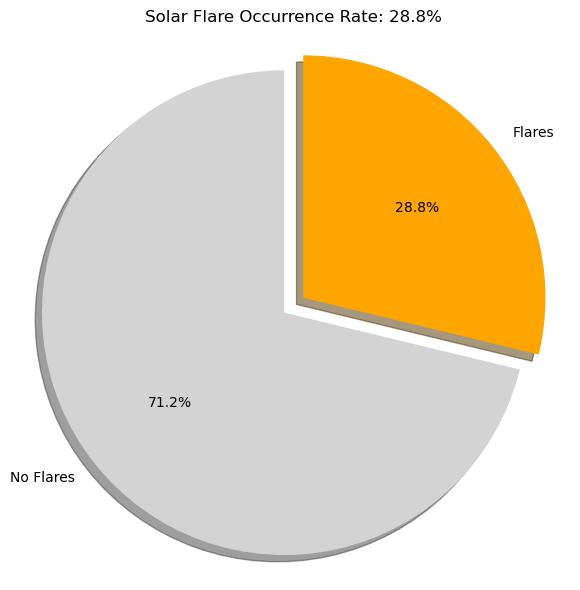

In [7]:
import matplotlib.pyplot as plt
P = df['Solar_Flare_Occurred'].mean()
print(f"Solar Flare Occurrence Rate: {P:.2f}")

# Create a pie chart
plt.figure(figsize=(6, 6))
flare_count = df['Solar_Flare_Occurred'].sum()
no_flare_count = len(df) - flare_count
sizes = [no_flare_count, flare_count]
colors = ['lightgray', 'orange']
explode = (0, 0.1)  # "explode" the flare slice

labels = ['No Flares', 'Flares']
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', startangle=90, shadow=True)
plt.title(f'Solar Flare Occurrence Rate: {P*100:.1f}%')
plt.axis('equal')  # Equal aspect ratio ensures pie is circular
plt.tight_layout()
plt.show()



Probability of exactly 3 flares in 7 days: 0.2145
Or as percentage: 21.45%


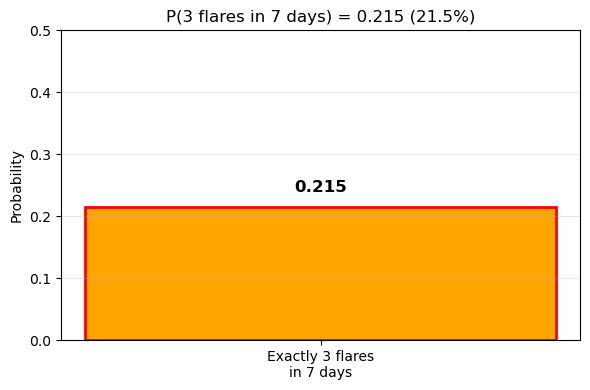

In [8]:
# Binomial probability for exactly 3 flares in 7 days
n = 7  # number of days
k = 3  # number of flares we want

# Calculate using formula: C(n,k) * p^k * (1-p)^(n-k)
probability = comb(n, k) * (P**k) * ((1-P)**(n-k))

print(f"\nProbability of exactly {k} flares in {n} days: {probability:.4f}")
print(f"Or as percentage: {probability*100:.2f}%")

import pandas as pd
import matplotlib.pyplot as plt
from math import comb
import numpy as np

# Load data and calculate probability
df = pd.read_csv('space_environment_dataset.csv')
p = df["Solar_Flare_Occurred"].mean()
n = 7
k = 3

# Calculate probability
probability = comb(n, k) * (p**k) * ((1-p)**(n-k))

# SIMPLE VISUALIZATION 1: Single bar chart
plt.figure(figsize=(6, 4))
plt.bar(['Exactly 3 flares\nin 7 days'], [probability], 
        color='orange', edgecolor='red', linewidth=2)
plt.ylabel('Probability')
plt.title(f'P(3 flares in 7 days) = {probability:.3f} ({probability*100:.1f}%)')
plt.ylim(0, 0.5)
plt.grid(True, axis='y', alpha=0.3)

# Add value on top of bar
plt.text(0, probability + 0.02, f'{probability:.3f}', 
         ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

Poisson Distribution (Micrometeoroid Impacts)
Impacts occur randomly.

Calculate the average rate:


In [9]:
lambda_val = df["Micrometeoroid_Impacts"].mean()
print(lambda_val)

5.010958904109589


the probability of 4 impacts occurring in a day

In [10]:
import pandas as pd
import numpy as np
from math import exp, factorial

# Load data and calculate lambda (average impacts per day)
df = pd.read_csv('space_environment_dataset.csv')
lambda_val = df["Micrometeoroid_Impacts"].mean()
k = 4  # number of impacts we want probability for

# Poisson formula: P(X=k) = (λ^k * e^(-λ)) / k!
probability = (lambda_val**k * exp(-lambda_val)) / factorial(k)

print("=" * 60)
print("POISSON PROBABILITY: MICROMETEOROID IMPACTS")
print("=" * 60)
print(f"Average impacts per day (λ): {lambda_val:.4f}")
print(f"Looking for probability of exactly {k} impacts in a day")
print(f"\nCalculated probability: {probability:.4f} ({probability*100:.2f}%)")

POISSON PROBABILITY: MICROMETEOROID IMPACTS
Average impacts per day (λ): 5.0110
Looking for probability of exactly 4 impacts in a day

Calculated probability: 0.1751 (17.51%)


Normal Distribution (Radiation)

Radiation levels are continuous.

Calculate mean and standard deviation:

In [11]:
mean_rad = df['Radiation_Level_mSv'].mean()
std_rad = df['Radiation_Level_mSv'].std()

print(f'average radiation level: {mean_rad:.2f} mSv')
print(f'std radiation level: {std_rad:.2f} mSv')

average radiation level: 49.43 mSv
std radiation level: 9.82 mSv


Radiation level for day 365

In [12]:
z = (63.8725741105259 - mean_rad) / std_rad
print(f"\nZ-score for 63.87 mSv: {z:.2f}")


Z-score for 63.87 mSv: 1.47


 Interpretion
z ≈ 1.47 is less than 2 → not unusually high (by the 2-sigma rule).

About 91% of normal data would be below this level, so it’s high but not extreme.

Visualizations

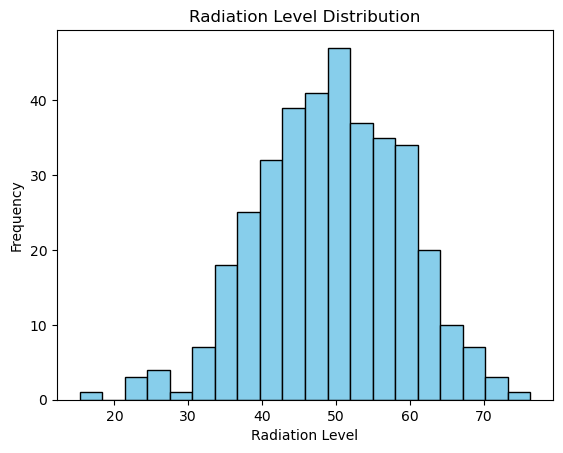

In [13]:
#Radiation Distribution
plt.hist(df["Radiation_Level_mSv"], bins=20, color='skyblue', edgecolor='black')
plt.title("Radiation Level Distribution")
plt.xlabel("Radiation Level")
plt.ylabel("Frequency")
plt.show()

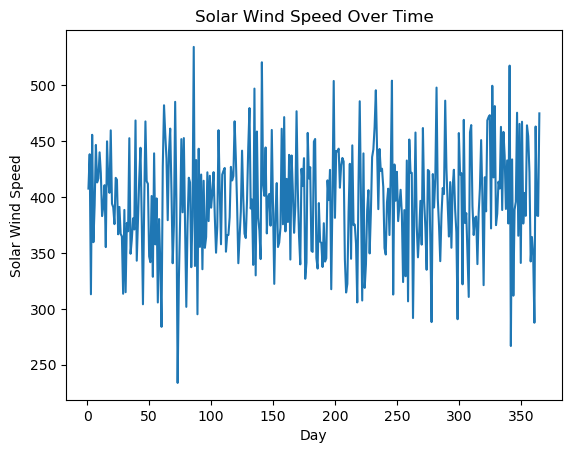

In [14]:
#Solar Wind Over Time
plt.plot(df["Day"], df["Solar_Wind_Speed_km_s"])
plt.title("Solar Wind Speed Over Time")
plt.xlabel("Day")
plt.ylabel("Solar Wind Speed")
plt.show()

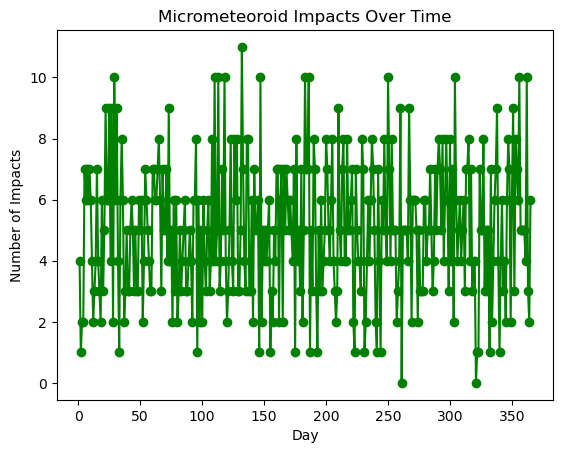

In [15]:
#meteoroid impacts over time
plt.plot(df["Day"], df["Micrometeoroid_Impacts"], marker='o', linestyle='-', color='green')
plt.title("Micrometeoroid Impacts Over Time")   
plt.xlabel("Day")
plt.ylabel("Number of Impacts")
plt.show()

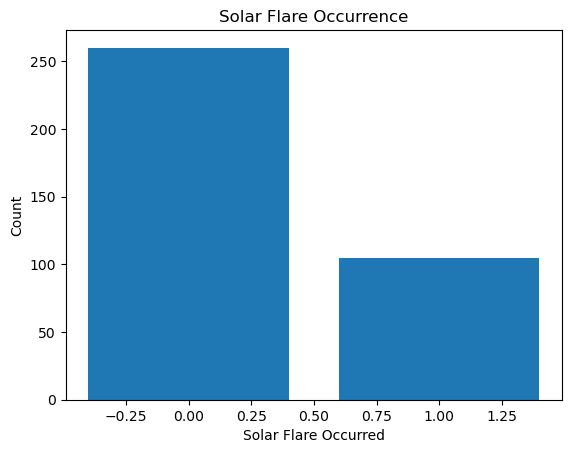

In [16]:
#Solar Flare Occurrence
plt.bar(df["Solar_Flare_Occurred"].value_counts().index, df["Solar_Flare_Occurred"].value_counts().values)
plt.title("Solar Flare Occurrence")
plt.xlabel("Solar Flare Occurred")
plt.ylabel("Count")
plt.show()

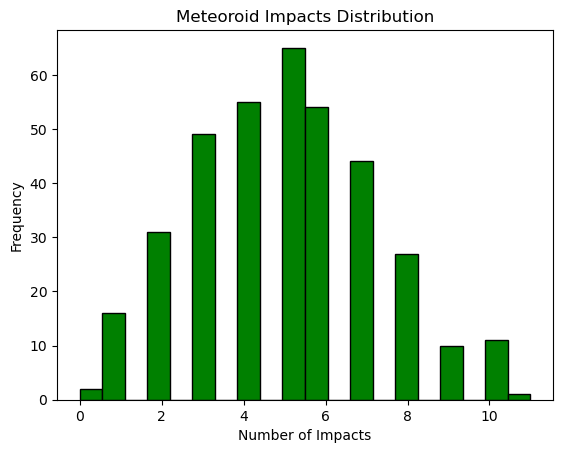

In [17]:
plt.hist(df["Micrometeoroid_Impacts"], bins=20, color='green', edgecolor='black')
plt.title("Meteoroid Impacts Distribution")
plt.xlabel("Number of Impacts")
plt.ylabel("Frequency")
plt.show()

 PROJECT INSIGHTS
From our analysis, we discovered:

Solar flares occur on about 28.8% of days, with a 21.45% chance of exactly 3 flares in any 7-day period

Micrometeoroid impacts average 5.01 per day, with a 17.5% chance of exactly 4 impacts on any given day

Radiation levels are normally distributed around 49.43 mSv, with most readings between 39.6 and 59.3 mSv (one standard deviation)

The highest radiation day (Day 248 with 76.34 mSv) had a z-score of 2.74, making it unusually high (only 0.3% of days would be this extreme)

